Cargar dataset bimestral

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

ruta_bimestral = "/content/drive/MyDrive/TFM/dataset_bimestral_v1.csv"

df_bim = pd.read_csv(
    ruta_bimestral,
    sep=";",
    encoding="utf-8-sig"
)

df_bim.head()

,periodo,consumo_total_m3,consumo_medio_m3,consumo_medio_diario_m3,abonados,domesticos,industriales,incidencias_sin_lectura,incidencias_normales,codigo_periodo,anio,bimestre
0,201 ENE-FEB/20,238430.0,24.421797,0.423523,9763,0,0,544,4207,201,2020,1
1,202 MAR-ABR/20,222732.0,22.746324,0.377438,9792,0,0,9053,423,202,2020,2
2,203 MAY-JUN/20,247689.0,25.194690,0.420694,9831,0,0,880,3833,203,2020,3
3,204 JUL-AGO/20,295567.0,28.793668,0.452773,10265,0,0,1348,4174,204,2020,4
4,205 SEP-OCT/20,273201.0,27.702393,0.448482,9862,0,0,1217,4268,205,2020,5


Se decide únicamente estudiar los datos a partir de 2022 inclusive por efecto pandemia

In [ ]:
df_modelo = df_bim[
    df_bim["anio"] >= 2022
].copy()

df_modelo.shape

(26, 12)

In [ ]:
df_modelo[["periodo","anio","bimestre"]]

,periodo,anio,bimestre
6,221 ENE-FEB/22,2022,1
7,222 MAR-ABR/22,2022,2
8,223 MAY-JUN/22,2022,3
9,224 JUL-AGO/22,2022,4
10,225 SEP-OCT/22,2022,5
11,226 NOV-DIC/22,2022,6
12,231 ENE-FEB/23,2023,1
13,232 MAR-ABR/23,2023,2
14,233 MAY-JUN/23,2023,3
15,234 JUL-AGO/23,2023,4


Pernoctaciones ISTAC Guía de Isora

In [ ]:
pernoctaciones_bimestre = {
    "221":127192,
    "222":144666,
    "223":119350,
    "224":262985,
    "225":170722,
    "226":189782,

    "231":236821,
    "232":179215,
    "233":102475,
    "234":157528,
    "235":169999,
    "236":142132,

    "241":235129,
    "242":251677,
    "243":203311,
    "244":267703,
    "245":227782,
    "246":175813,

    "251":182543,
    "252":180759,
    "253":177528,
    "254":212726,
    "255":177799,
    "256":172004,

    "261":187896,
    "262":190417
}

In [ ]:
df_modelo["codigo_periodo"] = (
    df_modelo["periodo"]
    .astype(str)
    .str[:3]
)

In [ ]:
df_modelo["pernoctaciones"] = (
    df_modelo["codigo_periodo"]
    .map(pernoctaciones_bimestre)
)

verificación

In [ ]:
df_modelo[
    [
        "periodo",
        "consumo_total_m3",
        "abonados",
        "pernoctaciones"
    ]
]

,periodo,consumo_total_m3,abonados,pernoctaciones
6,221 ENE-FEB/22,243489.0,10044,127192
7,222 MAR-ABR/22,243635.0,10057,144666
8,223 MAY-JUN/22,283579.0,10476,119350
9,224 JUL-AGO/22,269680.0,10097,262985
10,225 SEP-OCT/22,250460.0,10131,170722
11,226 NOV-DIC/22,302421.0,10551,189782
12,231 ENE-FEB/23,275121.0,10570,236821
13,232 MAR-ABR/23,257826.0,10202,179215
14,233 MAY-JUN/23,306095.0,10618,102475
15,234 JUL-AGO/23,317310.0,10640,157528


Correlación inmediata

In [ ]:
df_modelo[
    [
        "consumo_total_m3",
        "abonados",
        "pernoctaciones"
    ]
].corr()

,consumo_total_m3,abonados,pernoctaciones
consumo_total_m3,1.000000,0.870669,0.276662
abonados,0.870669,1.000000,0.180034
pernoctaciones,0.276662,0.180034,1.000000


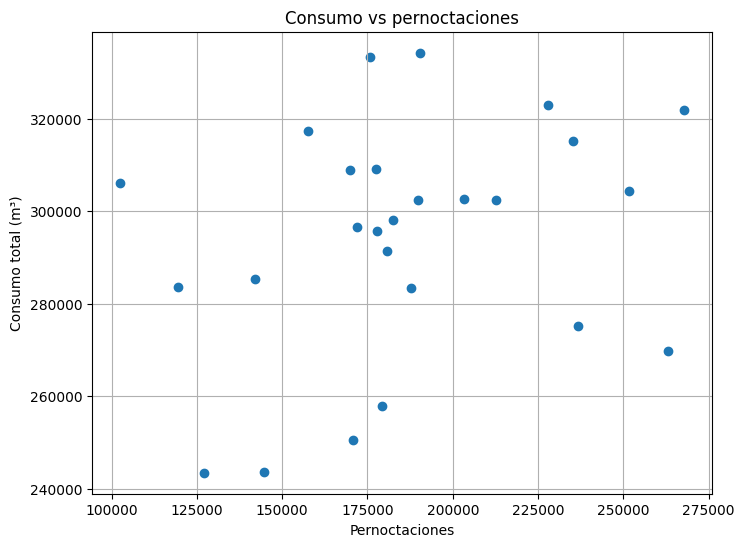

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_modelo["pernoctaciones"],
    df_modelo["consumo_total_m3"]
)

plt.xlabel("Pernoctaciones")
plt.ylabel("Consumo total (m³)")
plt.title("Consumo vs pernoctaciones")

plt.grid(True)

plt.show()

Una conclusión: la evolución de la demanda parece estar mucho más relacionada con el crecimiento estructural del sistema (abonados) que con las fluctuaciones turísticas.

¿Si aumenta ek turismo aumenta el consumo medio de cada abonado?

In [ ]:
df_modelo["consumo_por_abonado"] = (
    df_modelo["consumo_total_m3"] /
    df_modelo["abonados"]
)

In [ ]:
df_modelo[
    [
        "consumo_por_abonado",
        "pernoctaciones"
    ]
].corr()

,consumo_por_abonado,pernoctaciones
consumo_por_abonado,1.000000,0.295774
pernoctaciones,0.295774,1.000000


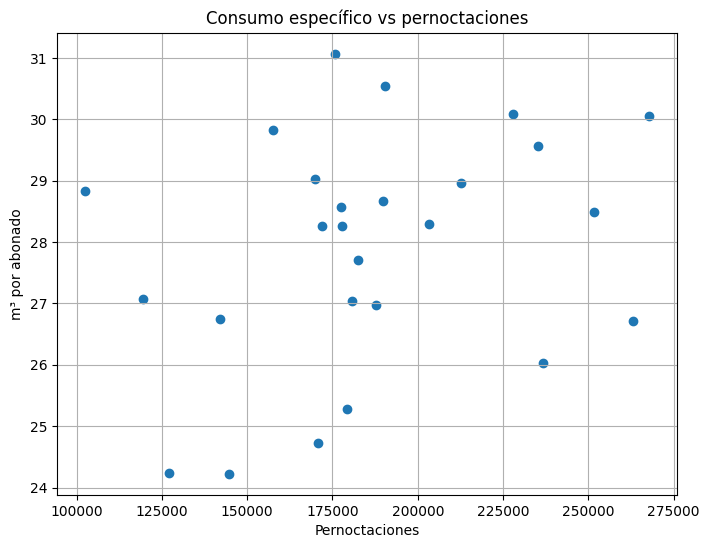

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_modelo["pernoctaciones"],
    df_modelo["consumo_por_abonado"]
)

plt.xlabel("Pernoctaciones")
plt.ylabel("m³ por abonado")

plt.title(
    "Consumo específico vs pernoctaciones"
)

plt.grid(True)

plt.show()

Antes de añadir otra variable externa, queremos saber la capacidad predictiva únicamente por el histórico de consumo

In [ ]:
df_modelo = df_modelo.sort_values(
    ["anio", "bimestre"]
).reset_index(drop=True)

In [ ]:
df_modelo["consumo_lag_1"] = (
    df_modelo["consumo_total_m3"]
    .shift(1)
)

df_modelo["consumo_lag_2"] = (
    df_modelo["consumo_total_m3"]
    .shift(2)
)

In [ ]:
df_modelo[
    [
        "periodo",
        "consumo_total_m3",
        "consumo_lag_1",
        "consumo_lag_2"
    ]
].head(10)

,periodo,consumo_total_m3,consumo_lag_1,consumo_lag_2
0,221 ENE-FEB/22,243489.0,NaN,NaN
1,222 MAR-ABR/22,243635.0,243489.0,NaN
2,223 MAY-JUN/22,283579.0,243635.0,243489.0
3,224 JUL-AGO/22,269680.0,283579.0,243635.0
4,225 SEP-OCT/22,250460.0,269680.0,283579.0
5,226 NOV-DIC/22,302421.0,250460.0,269680.0
6,231 ENE-FEB/23,275121.0,302421.0,250460.0
7,232 MAR-ABR/23,257826.0,275121.0,302421.0
8,233 MAY-JUN/23,306095.0,257826.0,275121.0
9,234 JUL-AGO/23,317310.0,306095.0,257826.0


Importancia de variables

In [ ]:
df_modelo[
    [
        "consumo_total_m3",
        "abonados",
        "pernoctaciones",
        "consumo_lag_1",
        "consumo_lag_2"
    ]
].corr()

,consumo_total_m3,abonados,pernoctaciones,consumo_lag_1,consumo_lag_2
consumo_total_m3,1.000000,0.870669,0.276662,0.482075,0.301686
abonados,0.870669,1.000000,0.180034,0.514227,0.450535
pernoctaciones,0.276662,0.180034,1.000000,0.405956,-0.017395
consumo_lag_1,0.482075,0.514227,0.405956,1.000000,0.540809
consumo_lag_2,0.301686,0.450535,-0.017395,0.540809,1.000000


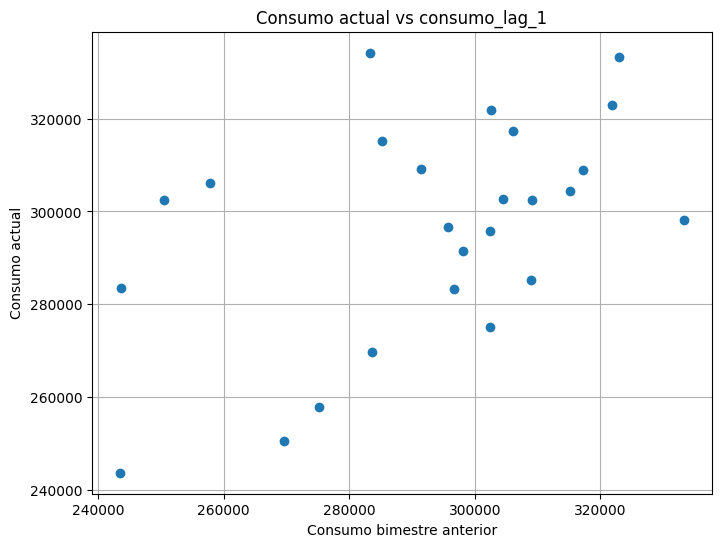

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_modelo["consumo_lag_1"],
    df_modelo["consumo_total_m3"]
)

plt.xlabel("Consumo bimestre anterior")
plt.ylabel("Consumo actual")
plt.title("Consumo actual vs consumo_lag_1")

plt.grid(True)

plt.show()

Comprobación lectura datos meteorlógicos

In [ ]:
import glob
import pandas as pd

ruta_datos = "/content/drive/MyDrive/TFM/datos"

archivos_met = glob.glob(
    ruta_datos + "/datos-meteorologicos-diarios-alcala-*.csv"
)

print(archivos_met)

['/content/drive/MyDrive/TFM/datos/datos-meteorologicos-diarios-alcala-2022.csv', '/content/drive/MyDrive/TFM/datos/datos-meteorologicos-diarios-alcala-2025.csv', '/content/drive/MyDrive/TFM/datos/datos-meteorologicos-diarios-alcala-2024.csv', '/content/drive/MyDrive/TFM/datos/datos-meteorologicos-diarios-alcala-2026.csv', '/content/drive/MyDrive/TFM/datos/datos-meteorologicos-diarios-alcala-2023.csv']


dataframe de meteorlo´gia

In [ ]:
import pandas as pd
import glob
import os

ruta_datos = "/content/drive/MyDrive/TFM/datos"

archivos_met = glob.glob(
    ruta_datos + "/datos-meteorologicos-diarios-alcala-*.csv"
)

lista_met = []

for archivo in archivos_met:
    df_temp = pd.read_csv(
        archivo,
        sep=",",
        encoding="utf-8",
        dtype=str
    )

    df_temp["archivo_origen"] = os.path.basename(archivo)
    lista_met.append(df_temp)

df_met = pd.concat(lista_met, ignore_index=True)

print(df_met.shape)
df_met.head()

(27624, 9)


,estacion_id,estacion_nombre,sensor_id,sensor_alias,sensor_nombre,fecha_observacion,metrica,valor,archivo_origen
0,95,ALCALA,450,WSP,Velocidad del viento,2022-01-01,total,NaN,datos-meteorologicos-diarios-alcala-2022.csv
1,95,ALCALA,450,WSP,Velocidad del viento,2022-01-01,media,0.459722,datos-meteorologicos-diarios-alcala-2022.csv
2,95,ALCALA,450,WSP,Velocidad del viento,2022-01-01,minimo,0.0,datos-meteorologicos-diarios-alcala-2022.csv
3,95,ALCALA,450,WSP,Velocidad del viento,2022-01-01,maximo,1.7,datos-meteorologicos-diarios-alcala-2022.csv
4,95,ALCALA,450,WSP,Velocidad del viento,2022-01-02,total,NaN,datos-meteorologicos-diarios-alcala-2022.csv


In [ ]:
df_met.info()
df_met.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27624 entries, 0 to 27623
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   estacion_id        27624 non-null  object
 1   estacion_nombre    27624 non-null  object
 2   sensor_id          27624 non-null  object
 3   sensor_alias       27624 non-null  object
 4   sensor_nombre      27624 non-null  object
 5   fecha_observacion  27624 non-null  object
 6   metrica            27624 non-null  object
 7   valor              18214 non-null  object
 8   archivo_origen     27624 non-null  object
dtypes: object(9)
memory usage: 1.9+ MB


['estacion_id',
 'estacion_nombre',
 'sensor_id',
 'sensor_alias',
 'sensor_nombre',
 'fecha_observacion',
 'metrica',
 'valor',
 'archivo_origen']

In [ ]:
df_met["sensor_nombre"].value_counts()

,count
sensor_nombre,
Temperatura,6464
Radiación solar,6464
Humedad relativa,6464
Velocidad del viento,6456
Precipitación,1776


In [ ]:
df_met["metrica"].value_counts()

,count
metrica,
total,6906
media,6906
minimo,6906
maximo,6906


In [ ]:
df_met[
    df_met["sensor_nombre"]
    .str.contains("temp", case=False, na=False)
].head(20)

,estacion_id,estacion_nombre,sensor_id,sensor_alias,sensor_nombre,fecha_observacion,metrica,valor,archivo_origen
1460,95,ALCALA,452,TEMP,Temperatura,2022-01-01,total,NaN,datos-meteorologicos-diarios-alcala-2022.csv
1461,95,ALCALA,452,TEMP,Temperatura,2022-01-01,media,17.4653,datos-meteorologicos-diarios-alcala-2022.csv
1462,95,ALCALA,452,TEMP,Temperatura,2022-01-01,minimo,10.1,datos-meteorologicos-diarios-alcala-2022.csv
1463,95,ALCALA,452,TEMP,Temperatura,2022-01-01,maximo,27.2,datos-meteorologicos-diarios-alcala-2022.csv
1464,95,ALCALA,452,TEMP,Temperatura,2022-01-02,total,NaN,datos-meteorologicos-diarios-alcala-2022.csv
1465,95,ALCALA,452,TEMP,Temperatura,2022-01-02,media,17.3993,datos-meteorologicos-diarios-alcala-2022.csv
1466,95,ALCALA,452,TEMP,Temperatura,2022-01-02,minimo,8.6,datos-meteorologicos-diarios-alcala-2022.csv
1467,95,ALCALA,452,TEMP,Temperatura,2022-01-02,maximo,27.7,datos-meteorologicos-diarios-alcala-2022.csv
1468,95,ALCALA,452,TEMP,Temperatura,2022-01-03,total,NaN,datos-meteorologicos-diarios-alcala-2022.csv
1469,95,ALCALA,452,TEMP,Temperatura,2022-01-03,media,17.2694,datos-meteorologicos-diarios-alcala-2022.csv


Creación de modelo con meteorlogía

In [ ]:
# Filtrar solo temperatura
df_temp = df_met[
    df_met["sensor_nombre"] == "Temperatura"
].copy()

# Convertir tipos
df_temp["fecha_observacion"] = pd.to_datetime(
    df_temp["fecha_observacion"],
    errors="coerce"
)

df_temp["valor"] = pd.to_numeric(
    df_temp["valor"],
    errors="coerce"
)

# Quedarnos solo con media y máxima diaria
df_temp = df_temp[
    df_temp["metrica"].isin(["media", "maximo"])
].copy()

# Crear año, mes y bimestre
df_temp["anio"] = df_temp["fecha_observacion"].dt.year
df_temp["mes"] = df_temp["fecha_observacion"].dt.month
df_temp["bimestre"] = ((df_temp["mes"] - 1) // 2) + 1

# Agregar por año, bimestre y métrica
temp_bimestral = (
    df_temp
    .groupby(["anio", "bimestre", "metrica"])["valor"]
    .mean()
    .reset_index()
)

# Pasar métricas a columnas
temp_bimestral = temp_bimestral.pivot_table(
    index=["anio", "bimestre"],
    columns="metrica",
    values="valor"
).reset_index()

# Renombrar columnas
temp_bimestral = temp_bimestral.rename(
    columns={
        "media": "temp_media_bimestre",
        "maximo": "temp_max_media_bimestre"
    }
)

temp_bimestral

metrica,anio,bimestre,temp_max_media_bimestre,temp_media_bimestre
0,2022,1,24.045763,18.271351
1,2022,2,23.583607,18.661957
2,2022,3,26.519672,21.520070
3,2022,4,28.980645,23.612840
4,2022,5,28.770492,23.053700
5,2022,6,26.659016,20.505702
6,2023,1,23.955932,17.807639
7,2023,2,26.472131,20.043545
8,2023,3,28.026230,22.348634
9,2023,4,30.782258,25.017350


In [ ]:
df_modelo = df_modelo.merge(
    temp_bimestral,
    on=["anio", "bimestre"],
    how="left"
)

df_modelo[
    [
        "periodo",
        "consumo_total_m3",
        "abonados",
        "pernoctaciones",
        "temp_media_bimestre",
        "temp_max_media_bimestre"
    ]
]

,periodo,consumo_total_m3,abonados,pernoctaciones,temp_media_bimestre,temp_max_media_bimestre
0,221 ENE-FEB/22,243489.0,10044,127192,18.271351,24.045763
1,222 MAR-ABR/22,243635.0,10057,144666,18.661957,23.583607
2,223 MAY-JUN/22,283579.0,10476,119350,21.520070,26.519672
3,224 JUL-AGO/22,269680.0,10097,262985,23.612840,28.980645
4,225 SEP-OCT/22,250460.0,10131,170722,23.053700,28.770492
5,226 NOV-DIC/22,302421.0,10551,189782,20.505702,26.659016
6,231 ENE-FEB/23,275121.0,10570,236821,17.807639,23.955932
7,232 MAR-ABR/23,257826.0,10202,179215,20.043545,26.472131
8,233 MAY-JUN/23,306095.0,10618,102475,22.348634,28.026230
9,234 JUL-AGO/23,317310.0,10640,157528,25.017350,30.782258


Correlaciones

In [ ]:
df_modelo[
    [
        "consumo_total_m3",
        "abonados",
        "pernoctaciones",
        "consumo_lag_1",
        "consumo_lag_2",
        "temp_media_bimestre",
        "temp_max_media_bimestre"
    ]
].corr()

,consumo_total_m3,abonados,pernoctaciones,consumo_lag_1,consumo_lag_2,temp_media_bimestre,temp_max_media_bimestre
consumo_total_m3,1.000000,0.870669,0.276662,0.482075,0.301686,0.267027,0.305345
abonados,0.870669,1.000000,0.180034,0.514227,0.450535,-0.012651,0.004457
pernoctaciones,0.276662,0.180034,1.000000,0.405956,-0.017395,0.103031,0.141585
consumo_lag_1,0.482075,0.514227,0.405956,1.000000,0.540809,0.085720,0.178819
consumo_lag_2,0.301686,0.450535,-0.017395,0.540809,1.000000,-0.231504,-0.174236
temp_media_bimestre,0.267027,-0.012651,0.103031,0.085720,-0.231504,1.000000,0.971513
temp_max_media_bimestre,0.305345,0.004457,0.141585,0.178819,-0.174236,0.971513,1.000000


Conclusiones

In [ ]:
df_modelo_final = df_modelo[
    [
        "periodo",
        "anio",
        "bimestre",
        "consumo_total_m3",
        "abonados",
        "pernoctaciones",
        "temp_media_bimestre",
        "consumo_lag_1",
        "consumo_lag_2"
    ]
].copy()

df_modelo_final.shape

(26, 9)

In [ ]:
ruta_final = "/content/drive/MyDrive/TFM/dataset_modelado_v1.csv"

df_modelo.to_csv(
    ruta_final,
    sep=";",
    index=False,
    encoding="utf-8-sig"
)